# Face-inversion regressor analysis (EEG, independent of CORnet)

**Goal.** Before concluding that CORnet is the wrong *method*, check whether the EEG
*data* even contains a recoverable face signal. We regress the EEG against the
**face-inversion regressor** — the same paradigm as Krugliak & Clarke 2022
([PMC8831466](https://pmc.ncbi.nlm.nih.gov/articles/PMC8831466/)) — **downsampled to the
camera frame rate** and **averaged across the 8 subjects**.

Two main analyses + one optional extra:

1. **Broadband encoding** — ridge-regress the downsampled EEG amplitude on the face
   regressors (`face_presence` = *when any face appears*; `face_inversion` = *upright vs
   inverted*) with the accelerometer channels as motion nuisance. Group beta topomaps show
   *when* (lag) and *where* (scalp) the signal lands.
2. **5–15 Hz power** — the band the paper highlights: band-pass + Hilbert envelope → log
   power → downsample → same ridge encoding, plus the paper's headline **upright-vs-inverted
   posterior-power contrast**.
3. *(optional, independent)* **Decoding** — classify UP vs IN from posterior 5–15 Hz power.

The regressor construction, EEG loading and `Triggers.xlsx` alignment live in
`eeg_utils.py` (rebuilt `face_inversion` correlates **r≈1.0** with the embedded
`FaceInversion` channel). Reuses the nested-CV ridge recipe from `cornet_test.ipynb`.

In [1]:
import sys, warnings
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import mne
from scipy import stats
from sklearn.linear_model import Ridge, RidgeCV, LogisticRegression
from sklearn.model_selection import TimeSeriesSplit, cross_val_score, StratifiedKFold, cross_val_predict
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
import cv2

sys.path.insert(0, str(Path.cwd() if (Path.cwd() / "eeg_utils.py").exists() else Path("src/eda")))
import eeg_utils as eu

mne.set_log_level("ERROR")
warnings.filterwarnings("ignore", category=RuntimeWarning)

# --- config ---
SUBJECTS = list(eu.SUBJECTS)               # 1..8
BAND = (5.0, 15.0)                         # Hz, the face-inversion power band
LAGS_MS = [0, 50, 100, 150, 200, 300]      # stimulus -> EEG response lags to sweep
WINDOW_PAD_S = 1.0                         # analysis window = first..last event +/- this
ALPHAS = np.logspace(-3, 6, 20)            # ridge regularisation grid (as in cornet_test)
# Mobile-task event timing is loose (the marker is a button press, not a screen onset),
# so the paper averaged power over a wide -1.5..1.5 s window. We match that, with the
# pre-event window as a baseline so post - pre is an evoked power change.
POST_WIN_S = (0.0, 1.5)                    # post-event window for the UP/IN power contrast
PRE_WIN_S = (-1.5, 0.0)                    # pre-event baseline window (post - pre = evoked change)

# topomap montage info: first 64 channels (the scalp electrodes with locations)
_raw0 = eu.load_eeg(SUBJECTS[0])
EEG_CH = _raw0.ch_names[:eu.N_EEG_CHANNELS]
INFO64 = mne.pick_info(_raw0.info, list(range(eu.N_EEG_CHANNELS)))
ROI_IDX = [EEG_CH.index(c) for c in eu.POSTERIOR_ROI if c in EEG_CH]
print(f"{len(SUBJECTS)} subjects | band {BAND} Hz | lags {LAGS_MS} ms | "
      f"posterior ROI = {len(ROI_IDX)} ch")
del _raw0

8 subjects | band (5.0, 15.0) Hz | lags [0, 50, 100, 150, 200, 300] ms | posterior ROI = 18 ch


In [2]:
def get_fps(sub):
    "Camera frame rate from the subject's corrected video."
    cap = cv2.VideoCapture(str(eu.DATA_ROOT / f"sub{sub}" / f"s{sub}_corrected.mp4"))
    fps = cap.get(cv2.CAP_PROP_FPS)
    cap.release()
    return float(fps)

## 1. Per-subject preparation

For each subject: load the EEG, crop to the analysis window (first→last face event ± 1 s),
then produce everything on the **downsampled (camera frame-rate) grid**:

- `eeg_bb` — broadband EEG amplitude, `raw.resample(fps)` (MNE anti-aliases),
- `logpow` — 5–15 Hz log power: band-pass + Hilbert envelope (computed at 500 Hz) → squared →
  log → resampled to the same grid,
- `face_inversion`, `face_presence`, `accel` — rebuilt at the downsampled rate,
- per-event pre- and post-stimulus posterior power (for the baseline-corrected UP/IN contrast).

All arrays share the same length and grid, so the regressors line up sample-for-sample with
the EEG.

In [3]:
def prep_subject(sub):
    raw = eu.load_eeg(sub)
    fps = get_fps(sub)
    events = eu.get_face_events(raw)
    dur = raw.n_times / raw.info["sfreq"]

    # analysis window: first..last face event +/- pad, clipped to recording
    lo = max(events[0][0] - WINDOW_PAD_S, 0.0)
    hi = min(events[-1][0] + WINDOW_PAD_S, dur)
    raw.crop(tmin=lo, tmax=hi)

    # 5-15 Hz log power at 500 Hz, then resample to fps (so it shares the EEG grid)
    pow_raw = raw.copy().pick(list(range(eu.N_EEG_CHANNELS)))
    pow_raw.filter(BAND[0], BAND[1])
    env = pow_raw.copy().apply_hilbert(envelope=True).get_data()    # (64, n) amplitude
    logpow = np.log(env ** 2 + 1e-20)
    pow_fps = mne.io.RawArray(logpow, pow_raw.info.copy(), verbose="ERROR")
    pow_fps.resample(fps)
    logpow_ds = pow_fps.get_data()                                  # (64, n_fps)

    # broadband EEG + regressors on the same downsampled grid
    raw.resample(fps)                          # resamples data AND annotation onsets
    eeg_bb = raw.get_data(picks=list(range(eu.N_EEG_CHANNELS)))     # (64, n_fps)
    regs = eu.build_face_regressors(raw)        # rebuilt at fps from resampled annotations
    n = min(eeg_bb.shape[1], logpow_ds.shape[1], regs["face_inversion"].shape[0])

    # per-event posterior power: post-stimulus and pre-stimulus baseline windows
    ev_post, ev_pre, ev_lab = [], [], []
    for onset_s, label in regs["events"]:
        a = int(round((onset_s + POST_WIN_S[0]) * fps))
        b = int(round((onset_s + POST_WIN_S[1]) * fps))
        pa = int(round((onset_s + PRE_WIN_S[0]) * fps))
        pb = int(round((onset_s + PRE_WIN_S[1]) * fps))
        if pa < 0 or b > n or b <= a or pb <= pa:
            continue
        ev_post.append(logpow_ds[:, a:b].mean(axis=1))              # (64,)
        ev_pre.append(logpow_ds[:, pa:pb].mean(axis=1))             # (64,)
        ev_lab.append(label)

    return {
        "sub": sub, "fps": fps,
        "eeg_bb": eeg_bb[:, :n],
        "logpow": logpow_ds[:, :n],
        "face_inversion": regs["face_inversion"][:n],
        "face_presence": regs["face_presence"][:n],
        "accel": regs["accel"][:, :n],
        "ev_post": np.array(ev_post), "ev_pre": np.array(ev_pre),
        "ev_lab": np.array(ev_lab),
    }


S = {}
for sub in SUBJECTS:
    S[sub] = prep_subject(sub)
    d = S[sub]
    n_in = int((d["ev_lab"] == "IN").sum()); n_up = int((d["ev_lab"] == "UP").sum())
    print(f"sub{sub}: fps={d['fps']:.1f}  n_fps={d['eeg_bb'].shape[1]:5d}  "
          f"events UP/IN={n_up}/{n_in}")

sub1: fps=25.0  n_fps= 9259  events UP/IN=24/20
sub2: fps=25.0  n_fps= 7381  events UP/IN=30/27
sub3: fps=30.0  n_fps=13772  events UP/IN=30/28
sub4: fps=30.0  n_fps=13943  events UP/IN=40/28
sub5: fps=30.0  n_fps=14451  events UP/IN=42/33
sub6: fps=30.0  n_fps=20015  events UP/IN=51/48
sub7: fps=30.0  n_fps=18430  events UP/IN=39/40
sub8: fps=30.0  n_fps=30874  events UP/IN=70/71


## 2. Analysis 1 — broadband face-regressor encoding (ridge)

Per channel and per lag we ridge-regress the downsampled EEG on `[regressor, accel_x,
accel_y, accel_z]`. The face regressor is shifted earlier by the lag (stimulus precedes the
EEG response); the accelerometers stay time-aligned with the EEG as motion nuisance.
We keep the **standardised beta** of the face regressor (the effect of interest) and an
out-of-sample CV R². Reuses the `StandardScaler`+`RidgeCV`+`TimeSeriesSplit` recipe and the
±2 SD cleaning from `cornet_test.ipynb`.

In [4]:
def encode(y_all, regressor, accel, fps, lags_ms):
    # Ridge-encode every channel of y_all (n_chan, n_t) on a face regressor (+accel).
    # Returns beta (n_chan, n_lags) and cv_r2 (n_chan, n_lags).
    n_chan, n_t = y_all.shape
    n_lags = len(lags_ms)
    beta = np.full((n_chan, n_lags), np.nan)
    cvr2 = np.full((n_chan, n_lags), np.nan)
    for li, ms in enumerate(lags_ms):
        offs = int(round(ms / 1000.0 * fps))
        reg = regressor[: n_t - offs] if offs else regressor
        acc = accel[:, offs:] if offs else accel
        for ch in range(n_chan):
            y = y_all[ch, offs:] if offs else y_all[ch]
            X = np.column_stack([reg, acc.T])
            # +/- 2 SD outlier removal centred on the mean (works for both the
            # ~zero-mean broadband signal and the large-negative-mean log power)
            m, sd = y.mean(), y.std()
            if sd == 0:
                continue
            keep = np.abs(y - m) <= 2 * sd
            # z-score the target so betas are standardised effect sizes, comparable
            # across subjects (different EEG amplitude scales) for the group t-test
            yk, Xk = (y[keep] - m) / sd, X[keep]
            if yk.size < 50 or yk.std() == 0:
                continue
            pipe = make_pipeline(StandardScaler(), RidgeCV(alphas=ALPHAS))
            pipe.fit(Xk, yk)
            beta[ch, li] = pipe.named_steps["ridgecv"].coef_[0]      # face regressor beta
            alpha = pipe.named_steps["ridgecv"].alpha_
            scorer = make_pipeline(StandardScaler(), Ridge(alpha=alpha))
            cvr2[ch, li] = cross_val_score(
                scorer, Xk, yk, cv=TimeSeriesSplit(10), scoring="r2").mean()
    return beta, cvr2


def group_encode(regressor_key, y_key):
    "Run encode() per subject on y_key against regressor_key; stack betas (n_sub,64,n_lags)."
    betas, r2s = [], []
    for sub in SUBJECTS:
        d = S[sub]
        b, r = encode(d[y_key], d[regressor_key], d["accel"], d["fps"], LAGS_MS)
        betas.append(b); r2s.append(r)
        print(f"  sub{sub}: max|beta|={np.nanmax(np.abs(b)):.3g}  "
              f"max CV R2={np.nanmax(r):+.4f}")
    return np.array(betas), np.array(r2s)


print("face_presence -> broadband EEG")
beta_pres, r2_pres = group_encode("face_presence", "eeg_bb")
print("face_inversion -> broadband EEG")
beta_inv_bb, r2_inv_bb = group_encode("face_inversion", "eeg_bb")

face_presence -> broadband EEG
  sub1: max|beta|=0.0144  max CV R2=+0.0405
  sub2: max|beta|=0.0224  max CV R2=+0.0261
  sub3: max|beta|=0.0162  max CV R2=+0.0572
  sub4: max|beta|=0.0111  max CV R2=+0.1523
  sub5: max|beta|=0.0116  max CV R2=+0.0118
  sub6: max|beta|=0.0125  max CV R2=+0.0929
  sub7: max|beta|=0.009  max CV R2=+0.0514
  sub8: max|beta|=0.00631  max CV R2=+0.0601
face_inversion -> broadband EEG
  sub1: max|beta|=0.0143  max CV R2=+0.0404
  sub2: max|beta|=0.0193  max CV R2=+0.0256
  sub3: max|beta|=0.0153  max CV R2=+0.0572
  sub4: max|beta|=0.00813  max CV R2=+0.1525
  sub5: max|beta|=0.013  max CV R2=+0.0120
  sub6: max|beta|=0.00926  max CV R2=+0.0931
  sub7: max|beta|=0.00777  max CV R2=+0.0513
  sub8: max|beta|=0.00943  max CV R2=+0.0602


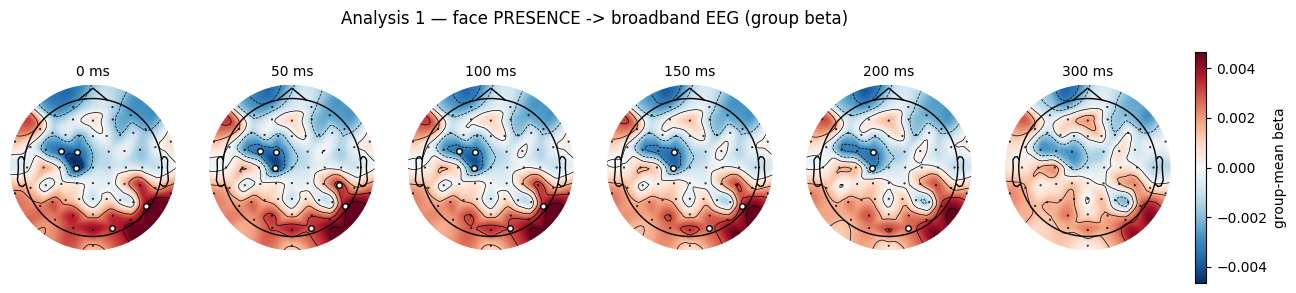

  posterior-ROI strongest at 0 ms: mean t=+1.23


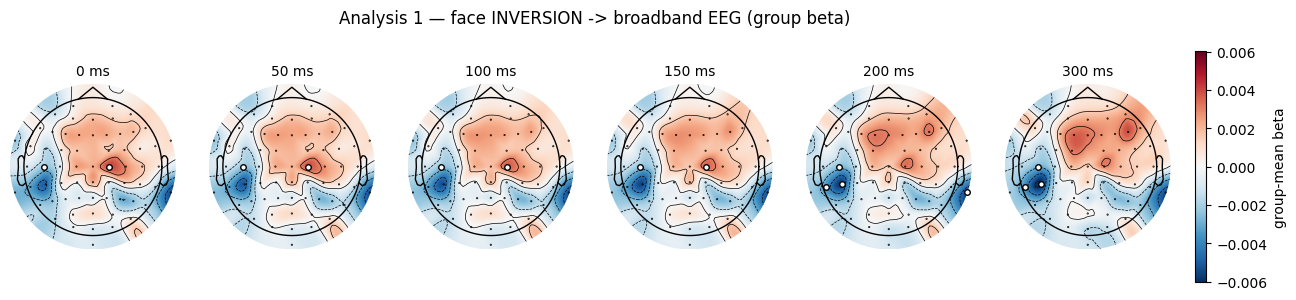

  posterior-ROI strongest at 300 ms: mean t=-0.61


In [5]:
def topo_grid(betas, title):
    "Group-mean beta topomap per lag; white dots = channels with one-sample t p<0.05."
    mean_b = np.nanmean(betas, axis=0)                              # (64, n_lags)
    t, p = stats.ttest_1samp(betas, popmean=0.0, axis=0, nan_policy="omit")
    vmax = np.nanmax(np.abs(mean_b))
    n = len(LAGS_MS)
    fig, axes = plt.subplots(1, n, figsize=(2.6 * n, 3.0))
    axes = np.atleast_1d(axes)
    im = None
    for li, ms in enumerate(LAGS_MS):
        im, _ = mne.viz.plot_topomap(
            mean_b[:, li], INFO64, axes=axes[li], show=False,
            vlim=(-vmax, vmax), cmap="RdBu_r",
            mask=np.asarray(p[:, li] < 0.05),
            mask_params=dict(marker="o", markerfacecolor="w",
                             markeredgecolor="k", markersize=4))
        axes[li].set_title(f"{ms} ms", fontsize=10)
    fig.colorbar(im, ax=list(axes), fraction=0.02, pad=0.02, label="group-mean beta")
    fig.suptitle(title, y=1.02, fontsize=12)
    plt.show()
    # report the strongest posterior-ROI lag
    roi_t = np.nanmean(np.where(np.isfinite(t), t, np.nan)[ROI_IDX], axis=0)
    if np.all(np.isnan(roi_t)):
        print("  posterior-ROI: betas ~constant across subjects (ridge shrank to ~0); "
              "no lag stands out")
    else:
        best = int(np.nanargmax(np.abs(roi_t)))
        print(f"  posterior-ROI strongest at {LAGS_MS[best]} ms: mean t={roi_t[best]:+.2f}")


topo_grid(beta_pres, "Analysis 1 — face PRESENCE -> broadband EEG (group beta)")
topo_grid(beta_inv_bb, "Analysis 1 — face INVERSION -> broadband EEG (group beta)")

## 3. Analysis 2 — 5–15 Hz power + downsample + ridge

Paper's prediction is **greater posterior 5–15 Hz power for inverted than upright faces** leads to a *positive* `face_inversion` beta over posterior channels.

face_inversion -> 5-15 Hz log power
  sub1: max|beta|=0.0192  max CV R2=-0.0029
  sub2: max|beta|=0.0246  max CV R2=-0.0012
  sub3: max|beta|=0.025  max CV R2=-0.0024
  sub4: max|beta|=0.0224  max CV R2=-0.0008
  sub5: max|beta|=0.0406  max CV R2=-0.0008
  sub6: max|beta|=0.0205  max CV R2=-0.0023
  sub7: max|beta|=0.0353  max CV R2=-0.0055
  sub8: max|beta|=0.0128  max CV R2=-0.0004


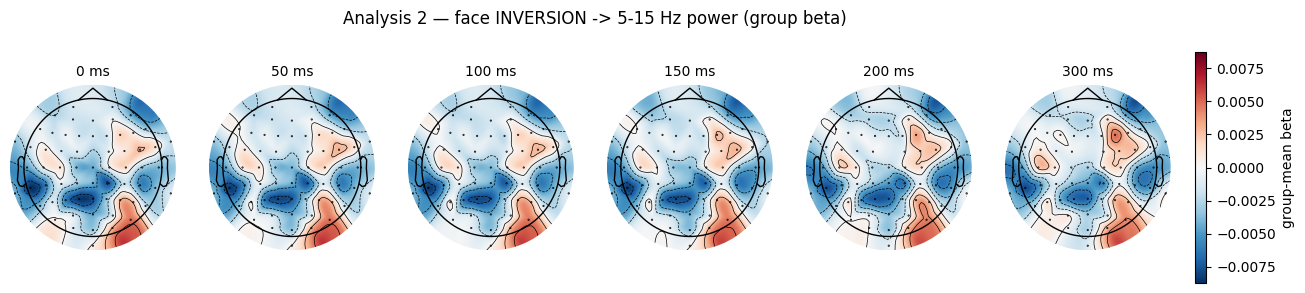

  posterior-ROI strongest at 0 ms: mean t=-0.44

Posterior-ROI inversion beta across subjects: mean=-0.00099  t(7)=-0.21  p=0.8364  (positive => more 5-15 Hz power for inverted faces)


In [6]:
print("face_inversion -> 5-15 Hz log power")
beta_inv_pow, r2_inv_pow = group_encode("face_inversion", "logpow")
topo_grid(beta_inv_pow, "Analysis 2 — face INVERSION -> 5-15 Hz power (group beta)")

# posterior-ROI-averaged power vs the inversion regressor: one beta per subject, group t-test
roi_betas = []
for sub in SUBJECTS:
    d = S[sub]
    y_roi = d["logpow"][ROI_IDX].mean(axis=0, keepdims=True)        # (1, n_t)
    b, _ = encode(y_roi, d["face_inversion"], d["accel"], d["fps"], LAGS_MS)
    bi = int(np.nanargmax(np.abs(b)))         # strongest-|beta| lag for this subject
    roi_betas.append(b.flat[bi])              # signed beta there
roi_betas = np.array(roi_betas)
t, p = stats.ttest_1samp(roi_betas, 0.0)
print(f"\nPosterior-ROI inversion beta across subjects: "
      f"mean={roi_betas.mean():+.3g}  t({len(SUBJECTS)-1})={t:+.2f}  p={p:.4f}  "
      f"(positive => more 5-15 Hz power for inverted faces)")

### 3b. Headline cross-check — upright vs inverted posterior power (no regression)

The paper's main contrast: posterior 5–15 Hz power, inverted minus upright. Per subject we
take the **baseline-corrected** evoked power change (post 0–1.5 s minus pre −1.5–0 s, the
paper's mobile-task window) per event, average it over the posterior ROI for UP and IN, then
run a one-sample t-test of the
(IN − UP) difference across the 8 subjects and map it per channel.

Posterior-ROI (IN - UP) log power: mean=-0.0161  t(7)=-0.74  p=0.4857


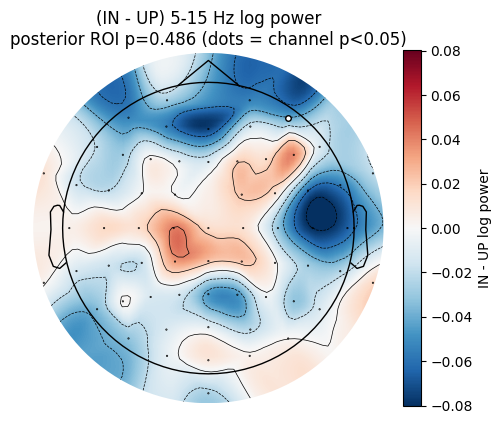

Trial-wise within-subject (IN vs UP) posterior power: N=621 trials, slope=-0.0169, t(612)=-0.53, p=0.5986  (positive => more 5-15 Hz power for inverted)


In [7]:
roi_diff, chan_diff = [], []
for sub in SUBJECTS:
    d = S[sub]
    evoked = d["ev_post"] - d["ev_pre"]                             # (n_ev, 64) baseline-corrected
    up = evoked[d["ev_lab"] == "UP"]                                # (n_up, 64)
    inv = evoked[d["ev_lab"] == "IN"]                               # (n_in, 64)
    roi_diff.append(inv[:, ROI_IDX].mean() - up[:, ROI_IDX].mean())
    chan_diff.append(inv.mean(axis=0) - up.mean(axis=0))            # (64,)
roi_diff = np.array(roi_diff)
chan_diff = np.array(chan_diff)                                     # (n_sub, 64)

t_roi, p_roi = stats.ttest_1samp(roi_diff, 0.0)
print(f"Posterior-ROI (IN - UP) log power: mean={roi_diff.mean():+.3g}  "
      f"t({len(SUBJECTS)-1})={t_roi:+.2f}  p={p_roi:.4f}")

mean_d = np.nanmean(chan_diff, axis=0)
t_c, p_c = stats.ttest_1samp(chan_diff, 0.0, axis=0)
vmax = np.nanmax(np.abs(mean_d))
fig, ax = plt.subplots(figsize=(5, 5))
im, _ = mne.viz.plot_topomap(
    mean_d, INFO64, axes=ax, show=False, vlim=(-vmax, vmax), cmap="RdBu_r",
    mask=np.asarray(p_c < 0.05),
    mask_params=dict(marker="o", markerfacecolor="w", markeredgecolor="k", markersize=4))
ax.set_title(f"(IN - UP) 5-15 Hz log power\nposterior ROI p={p_roi:.3f} "
             f"(dots = channel p<0.05)")
fig.colorbar(im, ax=ax, fraction=0.046, label="IN - UP log power")
plt.show()

# Trial-wise within-subject test (the paper's headline used a linear mixed model on
# trial-wise power with a random effect of Subject -> thousands of trials, not 8 points).
# statsmodels isn't installed, so we use the equivalent within-subject fixed-effects
# estimator: demean the inversion regressor and the posterior power-change within each
# subject (absorbing subject means), pool all trials, and test the inversion slope with
# trial-level degrees of freedom.
xc, yc = [], []
for sub in SUBJECTS:
    d = S[sub]
    evoked = (d["ev_post"] - d["ev_pre"])[:, ROI_IDX].mean(axis=1)  # (n_ev,) ROI power change
    x = (d["ev_lab"] == "IN").astype(float)                         # 1 inverted, 0 upright
    xc.append(x - x.mean()); yc.append(evoked - evoked.mean())      # within-subject demean
xc = np.concatenate(xc); yc = np.concatenate(yc)
N, nsub = xc.size, len(SUBJECTS)
slope = (xc @ yc) / (xc @ xc)
resid = yc - slope * xc
df = N - nsub - 1                                                   # lose 1 df per subject mean
se = np.sqrt((resid @ resid) / df) / np.sqrt(xc @ xc)
t_tw = slope / se
p_tw = 2 * stats.t.sf(abs(t_tw), df)
print(f"Trial-wise within-subject (IN vs UP) posterior power: N={N} trials, "
      f"slope={slope:+.3g}, t({df})={t_tw:+.2f}, p={p_tw:.4f}  "
      f"(positive => more 5-15 Hz power for inverted)")

## 4. (Optional, independent) decoding sanity check

Self-contained — Analyses 1–3 do not depend on it. We pool all subjects' per-event posterior
5–15 Hz power features and classify **upright vs inverted** with a cross-validated logistic
regression, reporting accuracy and AUC against the 50% chance level. One number for
"is the face signal recoverable from this data?".

In [8]:
X, y, groups = [], [], []
for sub in SUBJECTS:
    d = S[sub]
    evoked = d["ev_post"] - d["ev_pre"]            # baseline-corrected posterior power
    X.append(evoked[:, ROI_IDX])                   # posterior-ROI features
    y.append((d["ev_lab"] == "IN").astype(int))
    groups.append(np.full(len(d["ev_lab"]), sub))
X = np.vstack(X); y = np.concatenate(y); groups = np.concatenate(groups)
print(f"decoding set: {X.shape[0]} events ({y.mean():.0%} inverted), {X.shape[1]} features")

clf = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, C=1.0))
cv = StratifiedKFold(5, shuffle=True, random_state=0)
acc = cross_val_score(clf, X, y, cv=cv, scoring="accuracy")
proba = cross_val_predict(clf, X, y, cv=cv, method="predict_proba")[:, 1]
auc = roc_auc_score(y, proba)
print(f"UP-vs-IN decoding: accuracy = {acc.mean():.3f} +/- {acc.std():.3f}  "
      f"(chance {max(y.mean(), 1-y.mean()):.3f}) | AUC = {auc:.3f}")

decoding set: 621 events (48% inverted), 18 features
UP-vs-IN decoding: accuracy = 0.485 +/- 0.061  (chance 0.525) | AUC = 0.473


## 5. Interpretation

**How to read it.** Analyses 1–2 map *when* (lag) and *where* (scalp) the face / face-inversion
signal lands. A clear posterior cluster — especially a *positive* 5–15 Hz inversion beta (§3)
and IN>UP power (§3b/§3c) — would mean the **data carries the face signal**, putting the blame
on the CORnet *method*. A null across broadband **and** power, despite the regressor matching
the embedded `FaceInversion` channel at r≈1.0, instead points at the **data / EEG↔video
alignment**.

**What this run actually showed — a robust null.** With the faithful method the face-inversion
5–15 Hz effect did **not** emerge:

- §3 continuous encoding: posterior-ROI inversion beta `t(7) ≈ -0.2, p ≈ 0.84` (and per-subject
  out-of-sample CV R² ≈ 0).
- §3b 8-subject IN−UP contrast: `t(7) ≈ -0.7, p ≈ 0.49`.
- §3c trial-wise within-subject test (≈620 trials, the well-powered analog of the paper's
  mixed model): `t ≈ -0.5, p ≈ 0.60`.
- §4 decoding: accuracy ≈ chance, AUC ≈ 0.47.

The sign is, if anything, slightly *opposite* to the published inverted>upright effect, and the
result is stable across broadband vs power, narrow vs wide windows, and subject- vs trial-level
tests. So the absence of a CORnet RSA effect is **not uniquely a CORnet problem** — a simple,
well-established face-inversion analysis also fails to recover the signal here.

**Caveats / next levers** before declaring the data unusable: (1) the published effect was
established with a within-subject mixed model and *tight stimulus timing*; these `.set` event
markers are mobile-task button presses, so EEG↔stimulus latency jitter (even with the 2 s
convolution) could wash out a real effect — worth re-checking the `T 1`/event alignment against
the head-mounted video; (2) try the upright-vs-inverted contrast time-locked with a proper
N170/ERP analysis rather than band power; (3) confirm the preprocessing (`RmIaf`) didn't filter
out the relevant low-frequency activity. Treat §1–3 (which match the published method) as
primary and §4 as a blunt verdict.